##Load and Explore the Data




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##Data Exploration

In [ ]:
#Read Dataset
df = pd.read_csv("/content/sample_data/coupons.csv")

In [ ]:
#Printing first 10 rows of DataFrame
df.head(10)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
5,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [ ]:
#DataFrame Size(rows,column)
print(df.shape)

(12684, 26)


##Problems

In [ ]:
# Lets find the column details of the data frame such as data type, non null count

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [ ]:
# Renaming Column Names for Readability
df = df.rename(columns = {"Y" : "Coupon_acceptance"})
df.columns = df.columns.str.capitalize()
df = df.rename(columns = {"Maritalstatus" : "Marital_status"})
df = df.rename(columns = {"Carryaway" : "Takeout"})
print(df.columns)

Index(['Destination', 'Passanger', 'Weather', 'Temperature', 'Time', 'Coupon',
       'Expiration', 'Gender', 'Age', 'Marital_status', 'Has_children',
       'Education', 'Occupation', 'Income', 'Car', 'Bar', 'Coffeehouse',
       'Takeout', 'Restaurantlessthan20', 'Restaurant20to50',
       'Tocoupon_geq5min', 'Tocoupon_geq15min', 'Tocoupon_geq25min',
       'Direction_same', 'Direction_opp', 'Coupon_acceptance'],
      dtype='object')


##Data Cleaning - Finding Null Values
Problem- 2. Investigate the dataset for missing or problematic data.

In [ ]:
df.isnull().sum().sum()

np.int64(13370)

In [ ]:
#Number of Null Values in All Columns
print(df.isnull().sum())

Destination                 0
Passanger                   0
Weather                     0
Temperature                 0
Time                        0
Coupon                      0
Expiration                  0
Gender                      0
Age                         0
Marital_status              0
Has_children                0
Education                   0
Occupation                  0
Income                      0
Car                     12576
Bar                       107
Coffeehouse               217
Takeout                   151
Restaurantlessthan20      130
Restaurant20to50          189
Tocoupon_geq5min            0
Tocoupon_geq15min           0
Tocoupon_geq25min           0
Direction_same              0
Direction_opp               0
Coupon_acceptance           0
dtype: int64


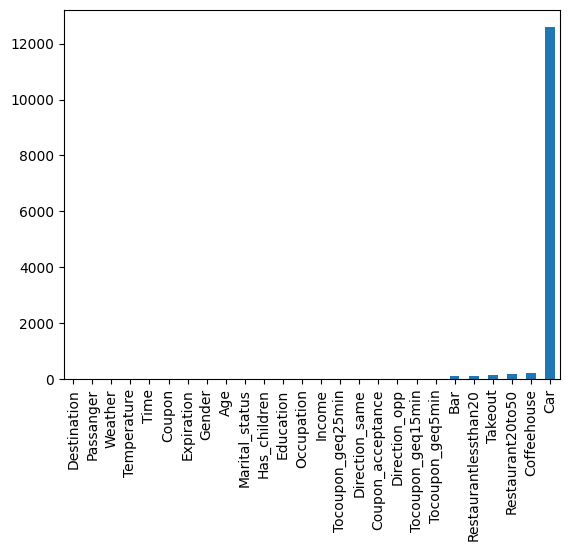

In [ ]:
#Graphical presentation of Null Values.
df.isnull().sum().sort_values().plot(kind = 'bar')
plt.show()

Columns "Car" has more number of null values(12576).Lets go deeper into this Car Column.

##Handling Missing Values & Filling
3. Decide what to do about your missing data -- drop, replace, other.

In [ ]:
#reaplace incorrect values and fill na values in CAR column
print(df['Car'].unique())
df['Car'] = df['Car'].fillna(value='no')
df = df.replace({'Car': {'Scooter and motorcycle' : 'yes', 'crossover':'yes', 'do not drive':'no',
                                'Car that is too old to install Onstar :D' : 'no', 'Mazda5':'yes'}})
print(df['Car'].unique())
df.isnull().sum()

[nan 'Scooter and motorcycle' 'crossover' 'Mazda5' 'do not drive'
 'Car that is too old to install Onstar :D']
['no' 'yes']


,0
Destination,0
Passanger,0
Weather,0
Temperature,0
Time,0
Coupon,0
Expiration,0
Gender,0
Age,0
Marital_status,0


#Percentage of Missing Values in ech columns

In [ ]:
#Missing Values Percentage per Column
df.isnull().sum()
missing_percentage_per_column = df.isnull().mean() * 100
print(missing_percentage_per_column)

# Calculate total missing values as a fraction of total cells and convert to percentage
total_missing_percentage = (df.isnull().sum().sum() / df.size) * 100
print(f"Total percentage of missing values in the dataset: {total_missing_percentage:.2f}%")

Destination             0.000000
Passanger               0.000000
Weather                 0.000000
Temperature             0.000000
Time                    0.000000
Coupon                  0.000000
Expiration              0.000000
Gender                  0.000000
Age                     0.000000
Marital_status          0.000000
Has_children            0.000000
Education               0.000000
Occupation              0.000000
Income                  0.000000
Car                     0.000000
Bar                     0.843582
Coffeehouse             1.710817
Takeout                 1.190476
Restaurantlessthan20    1.024913
Restaurant20to50        1.490066
Tocoupon_geq5min        0.000000
Tocoupon_geq15min       0.000000
Tocoupon_geq25min       0.000000
Direction_same          0.000000
Direction_opp           0.000000
Coupon_acceptance       0.000000
dtype: float64
Total percentage of missing values in the dataset: 0.24%


Based on above imputation, we are filling "mode values" in null. Because ignoring higher percentage of null values creates bias in our analysis

In [ ]:
print("Mode of Bar is: ",df['Bar'].mode())
print("Mode of Coffeehouse is: ",df['Coffeehouse'].mode())
print("Mode of Takeout is:",df['Takeout'].mode())
print("Mode of Restaurantlessthan20 is:",df['Restaurantlessthan20'].mode())
print("Mode of Restaurant20to50 is:",df['Restaurant20to50'].mode())
df.fillna(df.mode().iloc[0],inplace=True)
df.isnull().sum()

Mode of Bar is:  0    never
Name: Bar, dtype: object
Mode of Coffeehouse is:  0    less1
Name: Coffeehouse, dtype: object
Mode of Takeout is: 0    1~3
Name: Takeout, dtype: object
Mode of Restaurantlessthan20 is: 0    1~3
Name: Restaurantlessthan20, dtype: object
Mode of Restaurant20to50 is: 0    less1
Name: Restaurant20to50, dtype: object


,0
Destination,0
Passanger,0
Weather,0
Temperature,0
Time,0
Coupon,0
Expiration,0
Gender,0
Age,0
Marital_status,0


#Numerical Computation - Acceptance Ratio
4. What proportion of the total observations chose to accept the coupon?

In [ ]:
coupon_accepted = df['Coupon_acceptance'].value_counts()[1]
coupon_rejected = df['Coupon_acceptance'].value_counts()[0]
print("Coupon Accepted: ",coupon_accepted)
print("Coupon Rejected: ",coupon_rejected)
total_coupon_offered = df['Coupon_acceptance'].count()
acceptance_ratio = round(coupon_accepted/total_coupon_offered,2)
print("Acceptance Ratio: ",acceptance_ratio)
rejection_ratio = round(coupon_rejected/total_coupon_offered,2)
print("Rejection Ratio: ",rejection_ratio)

Coupon Accepted:  7210
Coupon Rejected:  5474
Acceptance Ratio:  0.57
Rejection Ratio:  0.43


In [ ]:
px.pie(df,names='Coupon_acceptance')


#Graphical view of which Coupon has higher Acceptance rate
5. Use a bar plot to visualize the `coupon` column.

['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']


Text(0.5, 1.0, 'Coupon Type by Count')

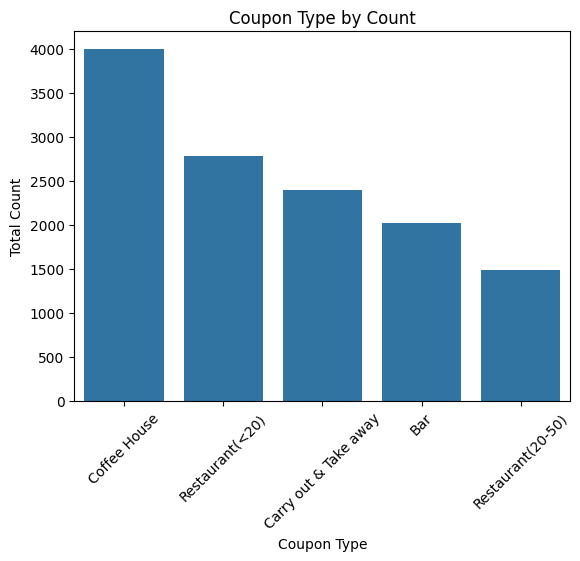

In [ ]:
print(df['Coupon'].unique())
g1 = sns.barplot(x=df.Coupon.value_counts().index, y=df.Coupon.value_counts())
g1.tick_params(axis='x', rotation=45)
g1.set(xlabel='Coupon Type', ylabel='Total Count')
g1.set_title('Coupon Type by Count')


6. Use a histogram to visualize the temperature column.

In [ ]:
px.histogram(df, x='Temperature', y='Coupon_acceptance',title='Temperature Histogram')

@Findings = Coffee coupons seems to be higher accpetance from customer

In [ ]:
fig= px.box(df, x="Weather", y="Coupon", color="Coupon_acceptance")
fig.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.

In [ ]:
df_Coupon_Bar = df.loc[df['Coupon'] == "Bar"]
df_Coupon_Bar.head()

,Destination,Passanger,Weather,Temperature,Time,Coupon,Expiration,Gender,Age,Marital_status,...,Coffeehouse,Takeout,Restaurantlessthan20,Restaurant20to50,Tocoupon_geq5min,Tocoupon_geq15min,Tocoupon_geq25min,Direction_same,Direction_opp,Coupon_acceptance
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [ ]:
df_Coupon_Bar.shape

(2017, 26)

2. What proportion of bar coupons were accepted?

In [ ]:
BarCoupon_accepted = df_Coupon_Bar['Coupon_acceptance'].value_counts()[1]
Total_Bar_Coupons = df_Coupon_Bar['Coupon_acceptance'].count()
Bar_Coupons_acceptance_propotion = round((BarCoupon_accepted/Total_Bar_Coupons)*100,2)
print("Bar Coupons Acceptance Ratio: ",Bar_Coupons_acceptance_propotion)
px.pie(df_Coupon_Bar,names='Coupon_acceptance')

Bar Coupons Acceptance Ratio:  41.0


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.

In [ ]:
df['Bar'].unique()
Bar_frequent = ['gt8', '4~8']
df_Coupon_Bar['Bar_Frequent'] = df_Coupon_Bar['Bar'].isin(['gt8', '4~8']).astype(int)
df_Coupon_Bar['Bar_Frequent'].value_counts()

/tmp/ipython-input-1089844985.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
Bar_Frequent,
0,1818
1,199


In [ ]:
Bar_frequent_visitors_coupon_acceptance = df_Coupon_Bar.loc[df_Coupon_Bar['Bar_Frequent'] == 1]['Coupon_acceptance'].value_counts()[1]
Total_bar_coupon_offered_frequent_visitors = df_Coupon_Bar.query("Bar_Frequent == 1")['Coupon_acceptance'].count()
Proportion_of_bar_coupon_acceptance_frequent_visitors = round((Bar_frequent_visitors_coupon_acceptance/Total_bar_coupon_offered_frequent_visitors)*100,2)

print(Proportion_of_bar_coupon_acceptance_frequent_visitors)


76.88


In [ ]:
Bar_less_frequent_visitors_coupon_accepted = df_Coupon_Bar.query("Bar_Frequent == 0")['Coupon_acceptance'].value_counts()[1]
Total_bar_coupon_offered_less_frequent_visitors = df_Coupon_Bar.query("Bar_Frequent == 0")['Coupon_acceptance'].count()
Proportion_of_bar_coupon_acceptance_less_frequent_visitors = round((Bar_less_frequent_visitors_coupon_accepted/Total_bar_coupon_offered_less_frequent_visitors)*100,2)
Proportion_of_bar_coupon_acceptance_less_frequent_visitors

np.float64(37.07)

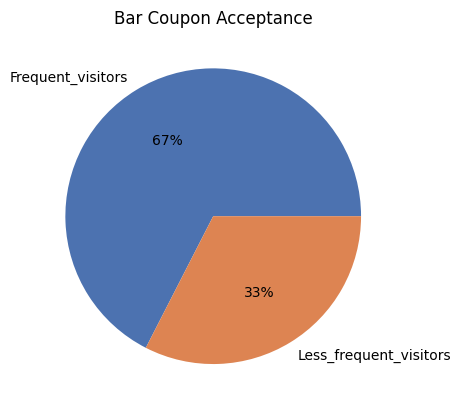

In [ ]:
Bar_data = [Proportion_of_bar_coupon_acceptance_frequent_visitors, Proportion_of_bar_coupon_acceptance_less_frequent_visitors]
labels = ['Frequent_visitors', 'Less_frequent_visitors']
colors = sns.color_palette('deep')
plt.pie(Bar_data, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Bar Coupon Acceptance')
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?

In [ ]:
df_bar_age_acceptance = df[['Age', 'Bar', 'Coupon_acceptance']].copy()

df_bar_age_acceptance['Bar_Visitor'] = df_bar_age_acceptance['Bar'].isin(['gt8', '4~8', '1~3', 'less1']).astype(int)

def categorize_age(age):
    try:
        age_int = int(age.replace('>', '').replace('<', '').replace('-', ''))
        if age_int > 25:
            return 'Over 25'
        else:
            return '25 or younger'
    except ValueError:
        return 'Unknown'

df_bar_age_acceptance['Age_Group'] = df_bar_age_acceptance['Age'].apply(categorize_age)

# Filter for drivers over 25 and who visit bars
filtered_group = df_bar_age_acceptance[(df_bar_age_acceptance['Bar_Visitor'] == 1) & (df_bar_age_acceptance['Age_Group'] == 'Over 25')]

# Calculate the acceptance rate for this group
acceptance_rate_filtered = round(filtered_group['Coupon_acceptance'].mean() * 100, 2)

print(f"Coupon acceptance rate for drivers over 25 and who visit bars: {acceptance_rate_filtered}%")
px.pie(df_bar_age_acceptance,names='Coupon_acceptance')

Coupon acceptance rate for drivers over 25 and who visit bars: 58.79%


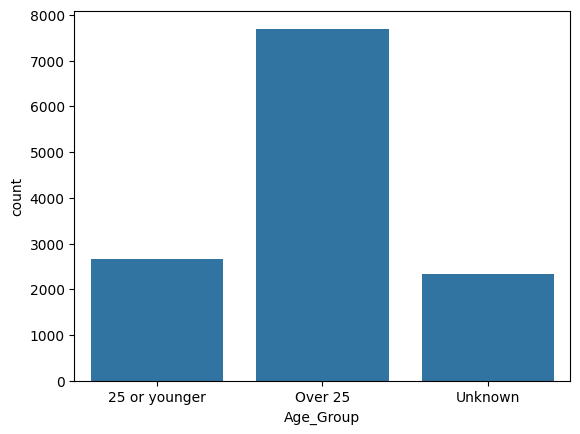

In [ ]:
sns.countplot(x=df_bar_age_acceptance['Age_Group'])
px.pie(df_bar_age_acceptance,names='Age_Group',title="Age Group who Visit Bar")

@Findings - From above observation, we could clearly see People Over the age of 25 tend to accept the Bar coupons more.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

In [ ]:
print(df_Coupon_Bar['Age'].unique())
print(df_Coupon_Bar['Occupation'].unique())

['21' '46' '26' '31' '41' '50plus' '36' 'below21']
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 'Transportation & Material Moving'
 'Business & Financial' 'Protective Service'
 'Food Preparation & Serving Related' 'Production Occupations'
 'Building & Grounds Cleaning & Maintenance' 'Farming Fishing & Forestry']


In [ ]:
def conditions(s):
    if s['Bar'] in ['1~3', 'gt8', '4~8'] and s['Age'] in ['21','46', '26', '31', '41', '50plus', '36'] and s['Occupation'] not in ['Farming Fishing & Forestry']:
        return 1
    else:
        return 0

# Let's create a new column based on the function above

df_Coupon_Bar['Bar_Frequent_Age_Job'] = df_Coupon_Bar.apply(conditions, axis=1)
df_Coupon_Bar['Bar_Frequent_Age_Job'].value_counts()

/tmp/ipython-input-2122484035.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
Bar_Frequent_Age_Job,
0,1431
1,586


In [ ]:
df_Coupon_Bar[['Bar','Age','Occupation','Bar_Frequent_Age_Job']].sample(20)

,Bar,Age,Occupation,Bar_Frequent_Age_Job
12437,never,50plus,Unemployed,0
276,never,31,Unemployed,0
11430,1~3,31,Sales & Related,1
2663,never,26,Architecture & Engineering,0
12247,less1,50plus,Business & Financial,0
1422,less1,36,Education&Training&Library,0
75,less1,46,Education&Training&Library,0
149,never,26,Unemployed,0
7956,never,31,Computer & Mathematical,0
4293,1~3,21,Education&Training&Library,1


In [ ]:
bar_coupon_accepted_more_frequent_visitors_elder_age_job = df_Coupon_Bar.query("Bar_Frequent_Age_Job == 1")['Coupon_acceptance'].value_counts()[1]

# Lets calculate the total bar coupon offered count for frequent visitors with elderly age and not farming/fishing job

total_bar_coupon_offered_frequent_visitors_elder_age_job = df_Coupon_Bar.query("Bar_Frequent_Age_Job == 1")['Coupon_acceptance'].count()

# Lets calculate the proportion of bar coupon acceptance from above values for frequent visitors with elderly age and not farming/fishing job

proportion_of_bar_coupon_acceptance_frequent_visitors_elderly_age_job = round((bar_coupon_accepted_more_frequent_visitors_elder_age_job/total_bar_coupon_offered_frequent_visitors_elder_age_job)*100,2)

proportion_of_bar_coupon_acceptance_frequent_visitors_elderly_age_job

np.float64(69.28)

In [ ]:
bar_coupon_accepted_less_frequent_visitors_younger_age_job = df_Coupon_Bar.query("Bar_Frequent_Age_Job == 0")['Coupon_acceptance'].value_counts()[1]

# Lets calculate the total bar coupon offered count for less frequent vistors with younger age and specific job

total_bar_coupon_offered_less_frequent_visitors_younger_age_job = df_Coupon_Bar.query("Bar_Frequent_Age_Job == 0")['Coupon_acceptance'].count()

# Lets calculate the proportion of bar coupon acceptance from above values for less frequent vistors with younger age and specific job

proportion_of_bar_coupon_acceptance_less_frequent_visitors_younger_age_job = round((bar_coupon_accepted_less_frequent_visitors_younger_age_job/total_bar_coupon_offered_less_frequent_visitors_younger_age_job)*100,2)

proportion_of_bar_coupon_acceptance_less_frequent_visitors_younger_age_job

np.float64(29.42)

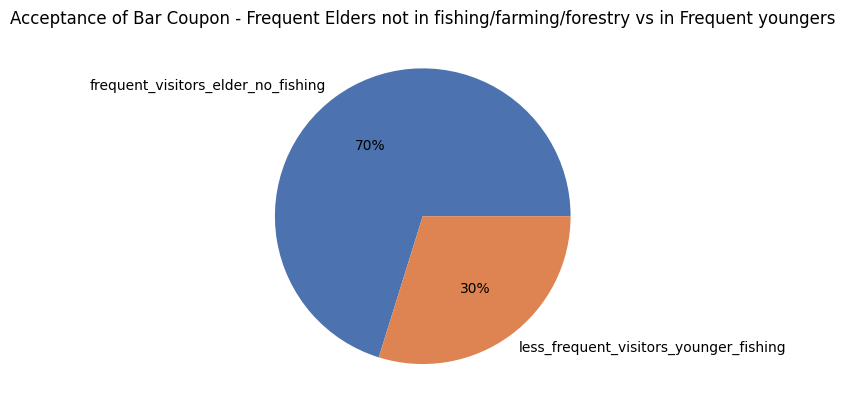

In [ ]:
data = [proportion_of_bar_coupon_acceptance_frequent_visitors_elderly_age_job, proportion_of_bar_coupon_acceptance_less_frequent_visitors_younger_age_job]
labels = ['frequent_visitors_elder_no_fishing', 'less_frequent_visitors_younger_fishing']

#define Seaborn color palette to use
colors = sns.color_palette('deep')[0:2]

#create pie chart
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.title('Acceptance of Bar Coupon - Frequent Elders not in fishing/farming/forestry vs in Frequent youngers')
plt.show()

Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?



The 'frequent elderly visitors' to bar have accepted the coupons to the most (69%) compared to 'less frequent young visitors' who have showed only less interest (33%).

The 'frequent elderly visitors without farming/fishing/forestry job' to bar have accepted the coupons to the most (70%) compared to 'less frequent young visitors with farming/fishing/forestry job' who have showed only less interest (30%).

The 'frequent younger visitors' to bar have accepted the coupons to the most (39%) compared to 'frequent visitors that are elder and widowed' who have slightly less interest (37%) or 'frequent visitors to cheap restaurants with low income' who have even less interest (24%).

In general, those drivers, who has the habit of going to bar more frequently are taking advantage of the coupon and acceoting the same more compared to anyone else.

Drivers who are within low income or use cheap restaurants does not much care about the bar coupons and that was evident from the outcomes.

##Independent Investigation
Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.

In [ ]:
Coffee_Coupon = df.loc[df['Coupon']== 'Coffee House']
Coffee_Coupon

,Destination,Passanger,Weather,Temperature,Time,Coupon,Expiration,Gender,Age,Marital_status,...,Coffeehouse,Takeout,Restaurantlessthan20,Restaurant20to50,Tocoupon_geq5min,Tocoupon_geq15min,Tocoupon_geq25min,Direction_same,Direction_opp,Coupon_acceptance
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


In [ ]:
Coffee_Coupon.shape

(3996, 26)

In [ ]:
fig= px.histogram(df, x ='Coupon', color='Coupon_acceptance', nbins=20)
fig.show()

@Finding

While one can normally think the weather could play a role in coffee consumption, but it was not creating any impact in acceptance of coupons. Infact, the acceptance was slightly low when snowy, so the guess is the driving comfort could have influenced.